In [4]:
import seaborn as sns
from sklearn.preprocessing  import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# DBSCAN

In [6]:
x,y= make_moons(
    n_samples=500,
    noise=0.1,
    random_state=42
)

In [12]:
scaler = StandardScaler()
x_scaled=scaler.fit_transform(x)

<Axes: >

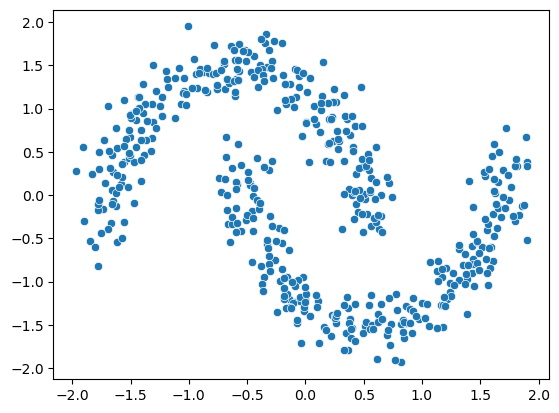

In [16]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1])

In [24]:
dbscan=DBSCAN(
    eps=0.2,
    min_samples=5)
labels=dbscan.fit_predict(x_scaled)

<Axes: >

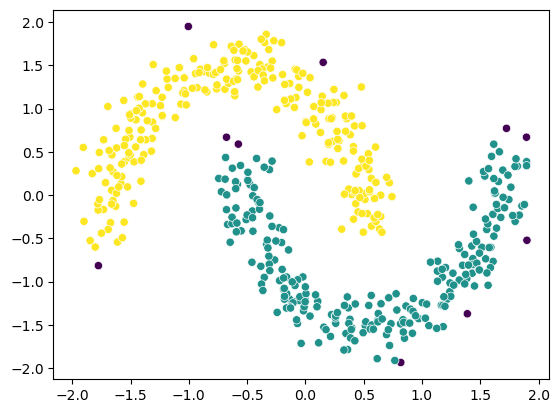

In [28]:
sns.scatterplot(x=x_scaled[:,0],y=x_scaled[:,1],c=labels)

# ISOLATION FOREST

In [35]:
import pandas as pd

In [48]:
df=pd.read_csv("thyroid_dataset.csv")

In [58]:
df.head

<bound method NDFrame.head of        Age  Sex  on_thyroxine  query_on_thyroxine  on_antithyroid_medication  \
0     0.45    1             0                   0                          0   
1     0.61    0             0                   0                          0   
2     0.16    0             1                   0                          0   
3     0.85    0             0                   0                          0   
4     0.75    1             0                   0                          0   
...    ...  ...           ...                 ...                        ...   
6911  0.65    0             1                   0                          0   
6912  0.77    0             0                   0                          0   
6913  0.41    0             0                   0                          0   
6914  0.64    1             0                   0                          0   
6915  0.46    0             0                   0                          0   

      sic

In [62]:
x=df.drop("Outlier_label", axis=1)
y=df["Outlier_label"]

In [64]:
x_scaled=scaler.fit_transform(x)

In [80]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [93]:
clf = IsolationForest(
    n_estimators=200,
    contamination=0.036,
    random_state=42
)

In [95]:
labels=clf.fit_predict(x_scaled)

In [97]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)

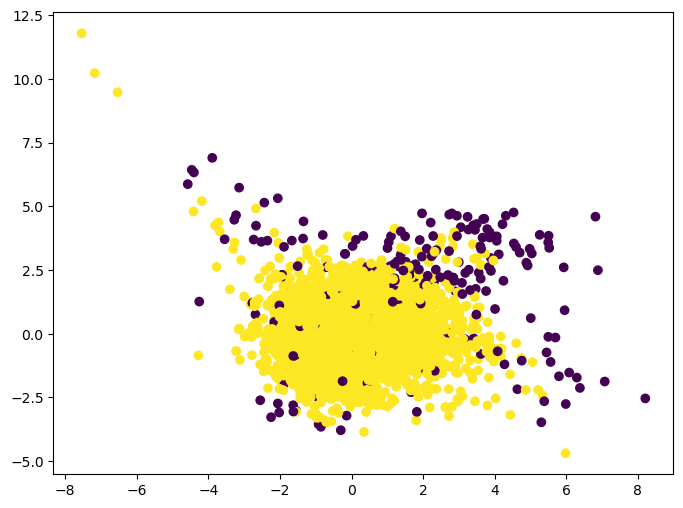

In [99]:
plt.figure(figsize=(8,6))
plt.scatter(x=x_pca[:,0],y=x_pca[:,1],c=labels)

In [101]:
import numpy as np 

n_out=np.sum(labels == -1)
n_normal=np.sum(labels==1)

print("out:",n_out)
print("nor:",n_normal)

out: 249
nor: 6667


# LOF

In [106]:
from sklearn.neighbors import LocalOutlierFactor

In [116]:
neighbour = LocalOutlierFactor(contamination=0.036)
labels=  neighbour.fit_predict(x_scaled)

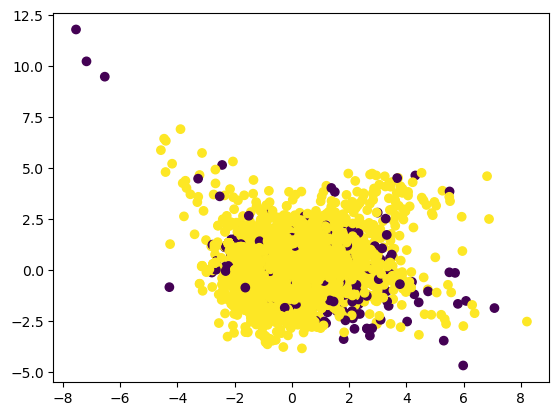

In [118]:
plt.scatter(x=x_pca[:,0],y=x_pca[:,1],c=labels)

In [120]:
n_out=np.sum(labels == -1)
n_normal=np.sum(labels==1)

print("out:",n_out)
print("nor:",n_normal)

out: 249
nor: 6667
